In [1]:
cd downloads

C:\Users\Fathima\anaconda3\envs\cnn310\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\Users\Fathima\downloads


In [2]:
cd Headset Classification Project

C:\Users\Fathima\downloads\Headset Classification Project


In [3]:
import cv2
import os
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import albumentations as A

In [4]:
#Read Raw Images
# CHANGE THIS to your dataset folder
folder = "C:/Users/Fathima/Downloads/Headset Classification Project"

IMG_SIZE = 160   # multiple of 32, works well with MobileNetV2

X = []
y = []

for label_name in os.listdir(folder):
    class_folder = os.path.join(folder, label_name)
    if not os.path.isdir(class_folder):
        continue

    for file in os.listdir(class_folder):
        img_path = os.path.join(class_folder, file)
        img = cv2.imread(img_path)

        if img is None:
            print("Skipping unreadable file:", img_path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)
        y.append(label_name)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)
print("Classes found:", np.unique(y))
print("Per-class counts:", {c: int((y == c).sum()) for c in np.unique(y)})

(986, 160, 160, 3)
(986,)
Classes found: ['Bluetooth' 'Wired']
Per-class counts: {np.str_('Bluetooth'): 514, np.str_('Wired'): 472}


In [5]:
#Label Encoding
label = LabelEncoder()
y_encoded = label.fit_transform(y)
print(label.classes_)   # e.g. ['Bluetooth' 'Wired']

['Bluetooth' 'Wired']


In [6]:
#Split RAW images FIRST (this is the leakage fix)
# 80% train+val, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# split the remaining 80% into train (80%) / val (20%)
X_train_raw, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Train (raw, before augmentation):", X_train_raw.shape)
print("Validation (untouched):", X_val.shape)
print("Test (untouched):", X_test.shape)

Train (raw, before augmentation): (630, 160, 160, 3)
Validation (untouched): (158, 160, 160, 3)
Test (untouched): (198, 160, 160, 3)


In [7]:
#Augment ONLY the training set
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.MedianBlur(p=0.3),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.75, 1.0), p=0.5),
])
# RandomResizedCrop added so the model can't just memorize fixed framing/background—
# it has to learn the actual object. VerticalFlip removed since headsets are never
# realistically photographed upside down.

AUGS_PER_IMAGE = 10

X_train_aug = []
y_train_aug = []

for img, lab in zip(X_train_raw, y_train):
    for _ in range(AUGS_PER_IMAGE):
        augmented = transform(image=img)
        X_train_aug.append(augmented["image"])
        y_train_aug.append(lab)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

# final training set = original train images + their augmented versions
X_train = np.concatenate((X_train_raw, X_train_aug), axis=0)
y_train = np.concatenate((y_train, y_train_aug), axis=0)

print("Final training set:", X_train.shape)
print("Validation set (unchanged, no augmentation):", X_val.shape)
print("Test set (unchanged, no augmentation):", X_test.shape)

Final training set: (6930, 160, 160, 3)
Validation set (unchanged, no augmentation): (158, 160, 160, 3)
Test set (unchanged, no augmentation): (198, 160, 160, 3)


In [8]:
#Preprocess with MobileNetV2's own normalization
X_train = preprocess_input(X_train.astype("float32"))
X_val = preprocess_input(X_val.astype("float32"))
X_test = preprocess_input(X_test.astype("float32"))

In [9]:
#Build the model — MobileNetV2 backbone (frozen) + small classifier head
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False   # freeze pretrained feature extractor

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(2, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
#Train
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 152s 655ms/step - accuracy: 0.7997 - loss: 0.4326 - val_accuracy: 0.8481 - val_loss: 0.3638
Epoch 2/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 137s 631ms/step - accuracy: 0.8792 - loss: 0.2685 - val_accuracy: 0.8418 - val_loss: 0.3906
Epoch 3/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 134s 619ms/step - accuracy: 0.9075 - loss: 0.2084 - val_accuracy: 0.8734 - val_loss: 0.4259
Epoch 4/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 140s 609ms/step - accuracy: 0.9244 - loss: 0.1719 - val_accuracy: 0.8608 - val_loss: 0.4272


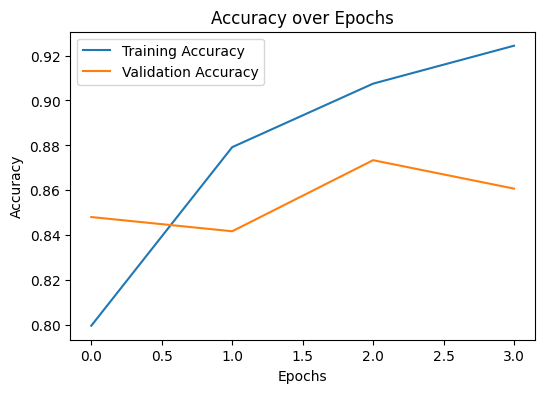

In [11]:
#Accuracy & Loss Graphs
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

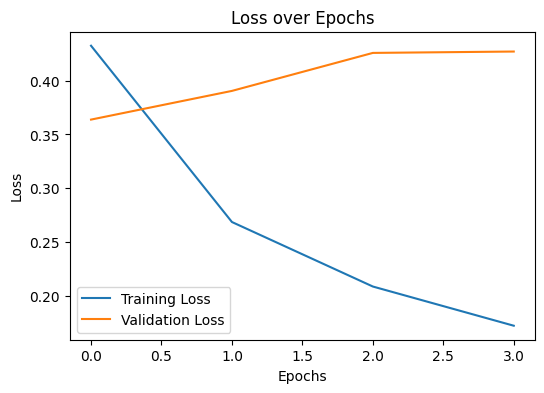

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 585ms/step


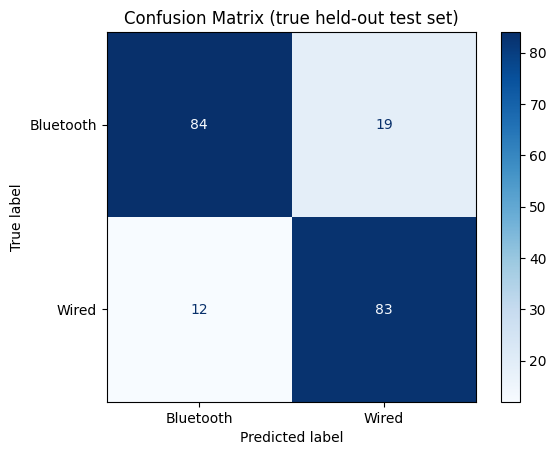

              precision    recall  f1-score   support

   Bluetooth       0.88      0.82      0.84       103
       Wired       0.81      0.87      0.84        95

    accuracy                           0.84       198
   macro avg       0.84      0.84      0.84       198
weighted avg       0.85      0.84      0.84       198



In [13]:
#Evaluate on the TRUE test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (true held-out test set)')
plt.show()

print(classification_report(y_test, y_pred, target_names=label.classes_))

In [14]:
#Prediction on a New Image
def predict_headset(img_path, threshold=70.0):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_input = preprocess_input(img_resized.astype("float32"))
    img_input = np.expand_dims(img_input, axis=0)

    prediction = model.predict(img_input)
    predicted_class = np.argmax(prediction, axis=1)[0]
    confidence = np.max(prediction) * 100

    if confidence < threshold:
        predicted_label = "Image Not Recognized / Not Found"
    else:
        predicted_label = label.inverse_transform([predicted_class])[0]

    print("Predicted Label:", predicted_label)
    print(f"Confidence: {confidence:.2f}%")

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    return predicted_label, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted Label: Bluetooth
Confidence: 98.88%


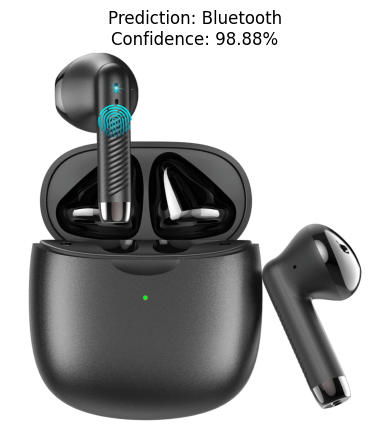

(np.str_('Bluetooth'), np.float32(98.87678))

In [15]:
# Example usage — change the path to any test image
predict_headset("C:/Users/Fathima/Downloads/lllll.jpg")

In [16]:
#Save the model
model.save("wired_bluetooth_headset_model_v2.keras")
print("Model saved successfully!")
print("Input shape:", model.input_shape)

Model saved successfully!
Input shape: (None, 160, 160, 3)


In [17]:
# Optional: Fine-tuning for extra accuracy
base_model.trainable = True

# freeze all but the last ~20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    callbacks=[early_stop]
)

model.save("wired_bluetooth_headset_model_v2_finetuned.keras")

Epoch 1/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 189s 794ms/step - accuracy: 0.8335 - loss: 0.3532 - val_accuracy: 0.8608 - val_loss: 0.3506
Epoch 2/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 170s 784ms/step - accuracy: 0.8773 - loss: 0.2790 - val_accuracy: 0.8608 - val_loss: 0.3444
Epoch 3/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 185s 706ms/step - accuracy: 0.8952 - loss: 0.2404 - val_accuracy: 0.8608 - val_loss: 0.3312
Epoch 4/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 142s 658ms/step - accuracy: 0.9105 - loss: 0.2187 - val_accuracy: 0.8671 - val_loss: 0.3201
Epoch 5/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 193s 612ms/step - accuracy: 0.9238 - loss: 0.1866 - val_accuracy: 0.8671 - val_loss: 0.3234


In [ ]:
#cd "C:\Users\Fathima\Downloads\Headset Classification Project"

In [ ]:
#streamlit run app.py